# Luminance Reconstruction Demo

This notebook demonstrates MPC-Flow for colorization from a luminance measurement. It compares an unconditional generation, MPC-Flow, and FlowChef using the same prompt and seed.

## 1. Imports

Load Python dependencies and the MPC-Flow functions used in this demo.

In [1]:
import os

import gc
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from matplotlib import pyplot as plt
from PIL import Image
from flux2.mpc import load_pipe, make_luminance_reward


## 2. Load FLUX.2

Set `repo_source` to `"hub"` to load from Hugging Face, or `"local"` to load from an existing Diffusers snapshot on disk.

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch_dtype = torch.bfloat16

hub_repo_id = "diffusers/FLUX.2-dev-bnb-4bit"
local_repo_snapshot = Path.home() / ".cache" / "huggingface" / "hub" / "models--diffusers--FLUX.2-dev-bnb-4bit" / "snapshots" / "c30ad107542e63f222f864a8de510204394fb18a"
repo_source = "local" if local_repo_snapshot.exists() else "hub"

repo_id = str(local_repo_snapshot) if repo_source == "local" else hub_repo_id
print("Repo source:", repo_source)
print("Repo id:", repo_id)

pipe = load_pipe(repo_id, torch_dtype=torch_dtype)
print("Device is", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(device))


Repo source: local
Repo id: C:\Users\gw23\.cache\huggingface\hub\models--diffusers--FLUX.2-dev-bnb-4bit\snapshots\c30ad107542e63f222f864a8de510204394fb18a


Loading weights:   0%|          | 0/585 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Device is cuda
GPU: NVIDIA GeForce RTX 5090


## 3. Demo Settings

Edit the prompt, reference image, image size, or optimizer settings here.

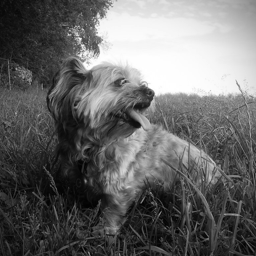

In [3]:
prompt = "colorize this luminance image"
reference_image_path = "prompt_images/dog.jpg"

height = 256
width = 256
steps = 28
guidance_scale = 4.0
seed = 42

mpc_num_steps = 20
mpc_opts = {"lr": 0.2, "rho": 1e-6, "inner_its": 20}

flowchef_num_steps = 20
flowchef_opts = {"lr": 0.2, "inner_its": 20}

results_dir = Path("output") / "notebooks" / "luminance"
results_dir.mkdir(parents=True, exist_ok=True)

reference_image_full = Image.open(reference_image_path).convert("RGB")
resize_scale = height / min(reference_image_full.size)
resize_size = (round(reference_image_full.width * resize_scale), round(reference_image_full.height * resize_scale))
reference_image = reference_image_full.resize(resize_size, Image.BICUBIC)
left = (reference_image.width - width) // 2
top = (reference_image.height - height) // 2
reference_image = reference_image.crop((left, top, left + width, top + height))
reference_arr = np.asarray(reference_image).astype(np.float32) / 255.0
luminance_arr = 0.299 * reference_arr[..., 0] + 0.587 * reference_arr[..., 1] + 0.114 * reference_arr[..., 2]
luminance_image = Image.fromarray(np.clip(luminance_arr * 255.0, 0, 255).astype(np.uint8), mode="L")
luminance_image


## 4. Encode The Prompt Once

Encode the prompt once and reuse the embeddings for all three generations.

In [4]:
max_sequence_length = 512
text_encoder_out_layers = (10, 20, 30)
num_images_per_prompt = 1

pipe.text_encoder.to(device)
with torch.no_grad():
    prompt_embeds, text_ids = pipe.encode_prompt(
        prompt=prompt,
        prompt_embeds=None,
        device=device,
        num_images_per_prompt=num_images_per_prompt,
        max_sequence_length=max_sequence_length,
        text_encoder_out_layers=text_encoder_out_layers,
    )
pipe.text_encoder.to("cpu")

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Prompt encoded once.")


c:\Users\gw23\AppData\Local\miniforge3\envs\mpcflow\Lib\site-packages\torch\nn\modules\module.py:1367: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:39.)
  return t.to(


Prompt encoded once.


## 5. Local Utilities

Define small utilities for timing, GPU memory reporting, measurement error, and repeated calls to the pipeline.

In [5]:
def sync_cuda():
    if torch.cuda.is_available():
        torch.cuda.synchronize(device)


def current_vram_gb():
    if not torch.cuda.is_available():
        return None, None
    return torch.cuda.memory_allocated(device) / (1024 ** 3), torch.cuda.memory_reserved(device) / (1024 ** 3)


def peak_vram_gb():
    if not torch.cuda.is_available():
        return None, None
    return torch.cuda.max_memory_allocated(device) / (1024 ** 3), torch.cuda.max_memory_reserved(device) / (1024 ** 3)


def psnr_np(pred, target):
    mse = np.mean((pred - target) ** 2)
    return float("inf") if mse == 0 else float(10.0 * np.log10(1.0 / mse))


def luminance_psnr(img):
    arr = np.asarray(img.convert("RGB").resize((width, height), Image.BICUBIC)).astype(np.float32) / 255.0
    lum = 0.299 * arr[..., 0] + 0.587 * arr[..., 1] + 0.114 * arr[..., 2]
    return psnr_np(lum, luminance_arr)


def gt_psnr(img):
    pred = np.asarray(img.convert("RGB").resize((width, height), Image.BICUBIC)).astype(np.float32) / 255.0
    target = np.asarray(reference_image).astype(np.float32) / 255.0
    return psnr_np(pred, target)


def fmt_gb(x):
    if x is None or pd.isna(x):
        return "N/A"
    return f"{x:.2f} GB"


def run_generation(label, *, num_mpc_steps, reward_dict, mpc_reward_name, mpc_method, mpc_opts=None, image=None, seed=42):
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)
    sync_cuda()

    start_allocated_gb, start_reserved_gb = current_vram_gb()
    gen = torch.Generator(device=str(device)).manual_seed(seed)
    start = time.perf_counter()
    out = pipe(
        image=image,
        prompt=None,
        prompt_embeds=prompt_embeds,
        text_ids=text_ids,
        height=height,
        width=width,
        num_inference_steps=steps,
        guidance_scale=guidance_scale,
        generator=gen,
        num_mpc_steps=num_mpc_steps,
        reward_dict=reward_dict,
        mpc_reward_name=mpc_reward_name,
        mpc_opts=mpc_opts,
        mpc_method=mpc_method,
        max_sequence_length=max_sequence_length,
        text_encoder_out_layers=text_encoder_out_layers,
    ).images[0]
    sync_cuda()
    elapsed_s = time.perf_counter() - start
    peak_allocated_gb, peak_reserved_gb = peak_vram_gb()
    opts = mpc_opts or {}
    return out, {
        "label": label,
        "method": mpc_method,
        "num_mpc_steps": num_mpc_steps,
        "lr": opts.get("lr"),
        "rho": opts.get("rho"),
        "inner_its": opts.get("inner_its"),
        "elapsed_s": elapsed_s,
        "start_vram_allocated_gb": start_allocated_gb,
        "start_vram_reserved_gb": start_reserved_gb,
        "peak_vram_allocated_gb": peak_allocated_gb,
        "peak_vram_reserved_gb": peak_reserved_gb,
        "avg_path_deviation": pipe.last_metrics.get("avg_path_deviation"),
    }


## 6. Unconditional Baseline

Generate an image conditioned on the luminance image and prompt, but without a luminance reward.

Begin image generation with mpc


  0%|          | 0/28 [00:00<?, ?it/s]

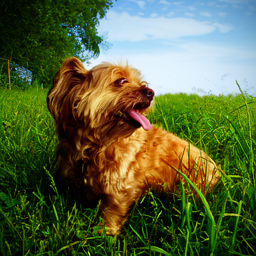

In [6]:
out_uncond, metrics_uncond = run_generation(
    "Unconditional",
    num_mpc_steps=0,
    reward_dict=None,
    mpc_reward_name=None,
    mpc_method="mpc",
    mpc_opts=None,
    image=luminance_image,
    seed=seed,
)

out_uncond


## 7. Luminance Reward

Build the differentiable objective that matches the generated image luminance to the measurement.

In [7]:
reward_fn = make_luminance_reward(luminance_image, device=device)
reward_dict = {"name": "luminance", "value_loss_fn": reward_fn}

print("Luminance reward is ready.")


Luminance reward is ready.


## 8. MPC-Flow And FlowChef

Run both methods with the same prompt embedding, luminance reward, and random seed.

In [8]:
out_mpc, metrics_mpc = run_generation(
    "MPC",
    num_mpc_steps=mpc_num_steps,
    reward_dict=reward_dict,
    mpc_reward_name="luminance",
    mpc_method="mpc",
    mpc_opts=mpc_opts,
    image=luminance_image,
    seed=seed,
)

out_flowchef, metrics_flowchef = run_generation(
    "FlowChef",
    num_mpc_steps=flowchef_num_steps,
    reward_dict=reward_dict,
    mpc_reward_name="luminance",
    mpc_method="flowchef",
    mpc_opts=flowchef_opts,
    image=luminance_image,
    seed=seed,
)

metrics_uncond["psnr_luminance"] = luminance_psnr(out_uncond)
metrics_mpc["psnr_luminance"] = luminance_psnr(out_mpc)
metrics_flowchef["psnr_luminance"] = luminance_psnr(out_flowchef)
metrics_uncond["psnr_gt"] = gt_psnr(out_uncond)
metrics_mpc["psnr_gt"] = gt_psnr(out_mpc)
metrics_flowchef["psnr_gt"] = gt_psnr(out_flowchef)

metrics_df = pd.DataFrame([metrics_uncond, metrics_mpc, metrics_flowchef]).set_index("label")
metric_cols = ["elapsed_s", "peak_vram_allocated_gb", "peak_vram_reserved_gb", "avg_path_deviation", "psnr_luminance", "psnr_gt"]
for col in metric_cols:
    metrics_df[col] = pd.to_numeric(metrics_df[col], errors="coerce").round(4)
metrics_df = metrics_df[metric_cols]

metrics_path = results_dir / "luminance_demo_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)
print(f"Saved metrics: {metrics_path}")
metrics_df


Begin image generation with mpc


  0%|          | 0/28 [00:00<?, ?it/s]

c:\Users\gw23\git\MPCFlow\FLUX2\flux2\mpc.py:293: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sigma_t = torch.tensor(self.scheduler.sigmas[i]).unsqueeze(0).to(latents.device)


Begin image generation with flowchef


  0%|          | 0/28 [00:00<?, ?it/s]

Saved metrics: output\notebooks\luminance\luminance_demo_metrics.csv


,elapsed_s,peak_vram_allocated_gb,peak_vram_reserved_gb,avg_path_deviation,psnr_luminance,psnr_gt
label,,,,,,
Unconditional,29.4687,17.6843,18.4707,0.0000,22.0984,17.9007
MPC,30.5104,18.4052,18.7031,0.0227,31.7102,23.6868
FlowChef,29.6801,18.4032,18.6934,0.1795,35.5156,19.3390


## 9. Qualitative Comparison

Compare the luminance measurement, reference image, and generated images.

Saved comparison: output\notebooks\luminance\luminance_demo_comparison.png


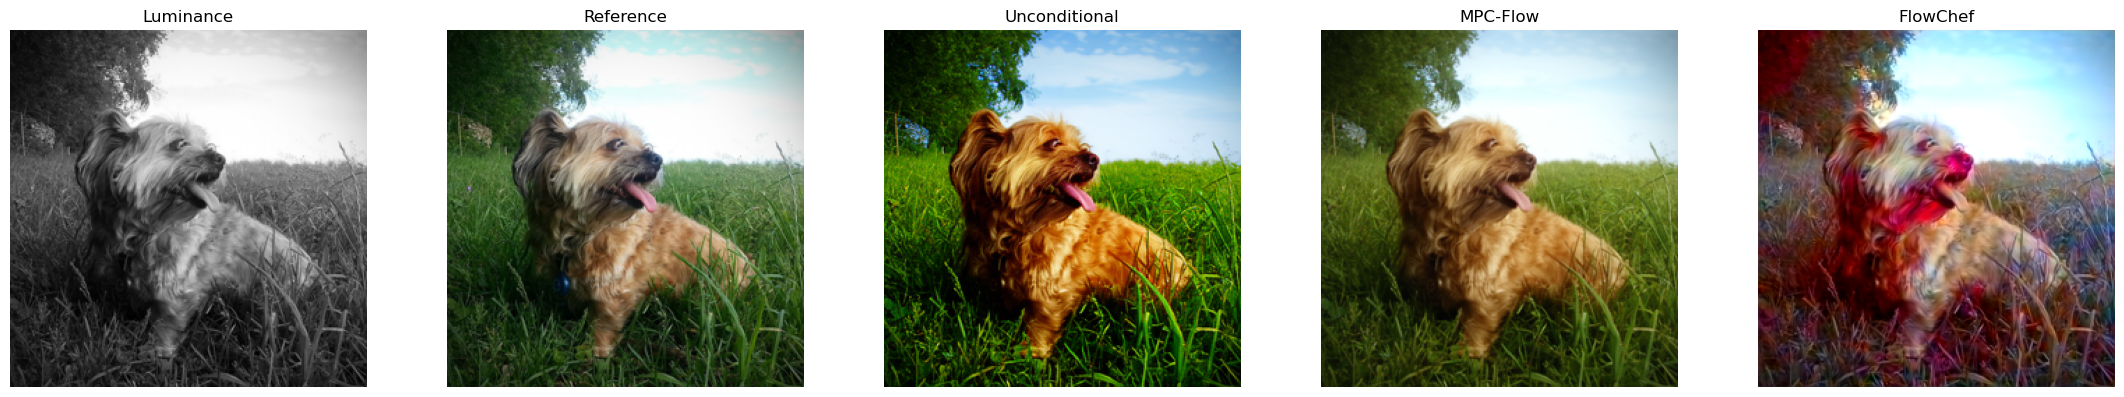

,elapsed_s,peak_vram_allocated_gb,peak_vram_reserved_gb,avg_path_deviation,psnr_luminance,psnr_gt
label,,,,,,
Unconditional,29.4687,17.6843,18.4707,0.0000,22.0984,17.9007
MPC,30.5104,18.4052,18.7031,0.0227,31.7102,23.6868
FlowChef,29.6801,18.4032,18.6934,0.1795,35.5156,19.3390


In [9]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
panels = [
    ("Luminance", luminance_image, "gray"),
    ("Reference", reference_image, None),
    ("Unconditional", out_uncond, None),
    ("MPC-Flow", out_mpc, None),
    ("FlowChef", out_flowchef, None),
]
for ax, (title, img, cmap) in zip(axes, panels):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")

comparison_path = results_dir / "luminance_demo_comparison.png"
fig.tight_layout()
fig.savefig(comparison_path, dpi=150, bbox_inches="tight")
print(f"Saved comparison: {comparison_path}")
plt.show()
metrics_df
